In [10]:
import pandas as pd
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# carregando o dataset
df = pd.read_json('News_Category_Dataset_v3.json', lines=True)
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [12]:
# separando em treino e teste
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)
# verificando tamanho de treino e teste
print(f'Tamanho do treino: {len(train)}')
print(f'Tamanho do teste: {len(test)}')

Tamanho do treino: 167621
Tamanho do teste: 41906


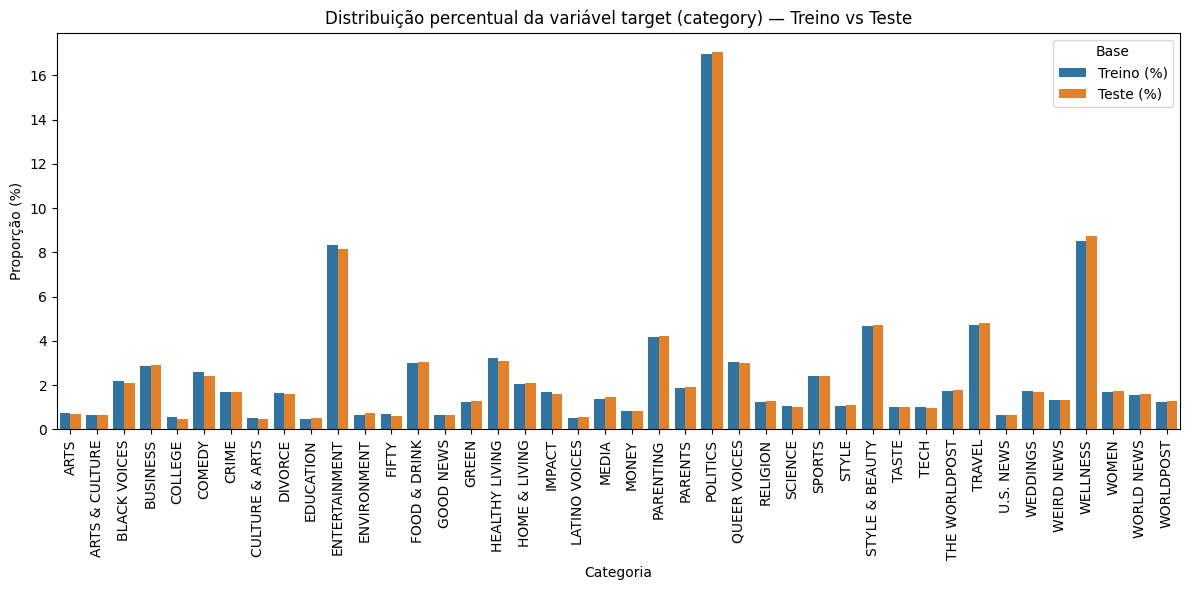

In [13]:
# Calcula as proporções em percentual
train_prop = train['category'].value_counts(normalize=True) * 100
test_prop = test['category'].value_counts(normalize=True) * 100

# Cria um DataFrame para comparação
proporcoes = pd.DataFrame({
    'Treino (%)': train_prop,
    'Teste (%)': test_prop
}).reset_index().rename(columns={'index': 'Categoria'})

# Plot do gráfico
plt.figure(figsize=(12, 6))
proporcoes_melted = proporcoes.melt(id_vars='category', var_name='Conjunto', value_name='Proporção (%)')

sns.barplot(data=proporcoes_melted, x='category', y='Proporção (%)', hue='Conjunto')
plt.xticks(rotation=90)
plt.title('Distribuição percentual da variável target (category) — Treino vs Teste')
plt.xlabel('Categoria')
plt.ylabel('Proporção (%)')
plt.legend(title='Base')
plt.tight_layout()
plt.show()

# Pré-processamento

In [14]:
import nltk
import re

In [15]:
train.dtypes

,0
link,object
headline,object
category,object
short_description,object
authors,object
date,datetime64[ns]


In [16]:
# excluindo coluna link e data que
train.drop( columns=['link','date'], axis=1, inplace=True)
train.head()

,headline,category,short_description,authors
3332,Owners Discuss Removing Trump's Name From Manh...,POLITICS,The building's residents are getting jittery a...,Mary Papenfuss
24930,Mandy Moore Shows Off Shiny New Engagement Rin...,ENTERTAINMENT,We couldn’t take our eyes off her shiny new ac...,"PureWow, ContributorWhat your girl crush reads..."
104193,Israel and Her Minorities,WORLDPOST,"If Israel wishes to be ""a light unto the natio...","Rabbi Michael M. Cohen, ContributorAuthor, 'Ei..."
6000,Officers Arrest Texas Student For Bringing Loa...,CRIME,The incident at a San Antonio middle school hi...,Sanjana Karanth
18391,The Best (Cheap) Places To Go In Europe This W...,TRAVEL,"BARCELONA, SPAIN Get your credit cards ready. ...","PureWow, ContributorWhat your girl crush reads..."


In [17]:
rename_map = {}
for col_name in train.columns:
  # passando para minúsculo e deixando apenas as letras
  train[col_name] = train[col_name].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x).lower())
  rename_map[col_name] = col_name.lower()
  train.rename(columns=rename_map, inplace=True)
train.head()

,headline,category,short_description,authors
3332,owners discuss removing trumps name from manha...,politics,the buildings residents are getting jittery ab...,mary papenfuss
24930,mandy moore shows off shiny new engagement rin...,entertainment,we couldnt take our eyes off her shiny new acc...,purewow contributorwhat your girl crush reads ...
104193,israel and her minorities,worldpost,if israel wishes to be a light unto the nation...,rabbi michael m cohen contributorauthor einste...
6000,officers arrest texas student for bringing loa...,crime,the incident at a san antonio middle school hi...,sanjana karanth
18391,the best cheap places to go in europe this winter,travel,barcelona spain get your credit cards ready we...,purewow contributorwhat your girl crush reads ...


In [18]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Baixar recursos necessários
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

# Inicializar stopwords e lematizador
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Função de limpeza completa
def preprocess_text(text):
    # 1. Converter para string e minúsculas
    text = str(text).lower()
    # 2. Tokenizar
    tokens = word_tokenize(text)
    # 3. Remover stopwords, pontuação e tokens curtos
    tokens = [w for w in tokens if w not in stop_words and w not in string.punctuation and len(w) > 2]
    # 4. Lematizar
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens

# Aplicar nas colunas de texto
for col in ['headline', 'short_description', 'authors','category']:
    train[col] = train[col].apply(preprocess_text)

# Exibir top 10 tokens de cada coluna
print("Top 10 tokens em 'headline':")
print(train['headline'].explode().value_counts().head(10))

print("\nTop 10 tokens em 'short_description':")
print(train['short_description'].explode().value_counts().head(10))

print("\nTop 10 tokens em 'authors':")
print(train['authors'].explode().value_counts().head(10))

print("Top 10 tokens em 'category':")
print(train['category'].explode().value_counts().head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Top 10 tokens em 'headline':
headline
trump     11273
photo      9822
new        7147
video      4953
say        4670
day        4297
donald     3872
woman      3779
make       3574
get        3508
Name: count, dtype: int64

Top 10 tokens em 'short_description':
short_description
one       11092
time       8776
new        8508
year       8321
people     7925
like       7380
day        6883
life       6559
said       6096
get        5832
Name: count, dtype: int64

Top 10 tokens em 'authors':
authors
contributor    30962
author          8696
writer          6105
reuters         5395
founder         3026
lee             2695
michael         2639
david           2483
moran           2417
blogger         2270
Name: count, dtype: int64
Top 10 tokens em 'category':
category
politics         28447
wellness         14273
entertainment    13943
voice             9671
style             9629
living            8833
travel            7879
beauty            7839
news              7097
parenting      

In [19]:
# Combinar as listas tokenizadas em uma string única para cada linha
train['combined_text'] = train['headline'] + train['short_description'] + train['authors']
train['combined_text'] = train['combined_text'].apply(lambda x: ' '.join(x))

In [20]:
# separação em X e Y
X_train = train['combined_text']
y_train = train['category'].apply(lambda x: ' '.join(x))

In [21]:
# Vetorização TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)

In [22]:
# Inicializar e treinar o modelo
model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model.fit(X_train_tfidf, y_train)

# Fazer predição no treino
y_pred = model.predict(X_train_tfidf)

# Avaliar
print("\n--- Training Data Classification Report ---")
print(classification_report(y_train, y_pred))


--- Training Data Classification Report ---
                precision    recall  f1-score   support

           art       0.72      0.49      0.59      1216
   art culture       0.84      0.53      0.65      1064
   black voice       0.74      0.53      0.61      3694
      business       0.65      0.62      0.63      4776
       college       0.68      0.51      0.58       942
        comedy       0.75      0.65      0.70      4378
         crime       0.65      0.65      0.65      2849
   culture art       0.83      0.42      0.56       872
       divorce       0.88      0.75      0.81      2762
     education       0.71      0.52      0.60       805
 entertainment       0.72      0.84      0.77     13943
   environment       0.80      0.34      0.47      1131
         fifty       0.81      0.35      0.49      1138
    food drink       0.79      0.85      0.82      5070
     good news       0.76      0.52      0.62      1128
         green       0.61      0.51      0.56      2090
he

In [23]:
# Realizar o mesmo processo em teste para testar
# excluindo coluna link e data que
test.drop( columns=['link','date'], axis=1, inplace=True)
test.head()

,headline,category,short_description,authors
128310,What If We Were All Family Generation Changers?,IMPACT,"What if, in doing so, we won't just create new...","Matt Murrie, ContributorEdupreneur, Cofounder/..."
139983,Firestorm At AOL Over Employee Benefit Cuts,BUSINESS,It should have been a glorious week for AOL ch...,
42339,Dakota Access Protesters Arrested As Deadline ...,POLITICS,A few protesters who refused to leave remained...,"Michael McLaughlin & Josh Morgan, The Huffingt..."
131494,One Glimpse Of These Baby Kit Foxes And You'll...,GREEN,,
163649,"Mens' Sweat Pheromone, Androstadienone, Influe...",SCIENCE,Scientists didn't know if humans played that g...,Melissa Cronin


In [24]:
rename_map = {}
for col_name in test.columns:
  # passando para minúsculo e deixando apenas as letras
  test[col_name] = test[col_name].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x).lower())
  rename_map[col_name] = col_name.lower()
  test.rename(columns=rename_map, inplace=True)
test.head()

,headline,category,short_description,authors
128310,what if we were all family generation changers,impact,what if in doing so we wont just create new op...,matt murrie contributoredupreneur cofounderchi...
139983,firestorm at aol over employee benefit cuts,business,it should have been a glorious week for aol ch...,
42339,dakota access protesters arrested as deadline ...,politics,a few protesters who refused to leave remained...,michael mclaughlin josh morgan the huffington...
131494,one glimpse of these baby kit foxes and youll ...,green,,
163649,mens sweat pheromone androstadienone influence...,science,scientists didnt know if humans played that ga...,melissa cronin


In [25]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Baixar recursos necessários
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inicializar stopwords e lematizador
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Função de limpeza completa
def preprocess_text(text):
    # 1. Converter para string e minúsculas
    text = str(text).lower()
    # 2. Tokenizar
    tokens = word_tokenize(text)
    # 3. Remover stopwords, pontuação e tokens curtos
    tokens = [w for w in tokens if w not in stop_words and w not in string.punctuation and len(w) > 2]
    # 4. Lematizar
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens

# Aplicar nas colunas de texto
for col in ['headline', 'short_description', 'authors','category']:
    test[col] = test[col].apply(preprocess_text)

# Exibir top 10 tokens de cada coluna
print("Top 10 tokens em 'headline':")
print(test['headline'].explode().value_counts().head(10))

print("\nTop 10 tokens em 'short_description':")
print(test['short_description'].explode().value_counts().head(10))

print("\nTop 10 tokens em 'authors':")
print(test['authors'].explode().value_counts().head(10))

print("Top 10 tokens em 'category':")
print(test['category'].explode().value_counts().head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Top 10 tokens em 'headline':
headline
trump     2779
photo     2542
new       1841
video     1249
say       1168
day       1105
donald     961
get        913
woman      901
make       887
Name: count, dtype: int64

Top 10 tokens em 'short_description':
short_description
one       2725
time      2266
new       2170
year      2072
people    1903
like      1849
day       1757
life      1566
said      1564
make      1530
Name: count, dtype: int64

Top 10 tokens em 'authors':
authors
contributor    7798
author         2271
writer         1503
reuters        1414
founder         794
michael         726
lee             649
david           618
travel          582
blogger         577
Name: count, dtype: int64
Top 10 tokens em 'category':
category
politics         7155
wellness         3672
entertainment    3419
style            2439
voice            2389
living           2181
travel           2021
beauty           1975
parenting        1768
news             1754
Name: count, dtype: int64


In [26]:
# Combinar as listas tokenizadas em uma string única para cada linha
test['combined_text'] = test['headline'] + test['short_description'] + test['authors']
test['combined_text'] = test['combined_text'].apply(lambda x: ' '.join(x))

In [27]:
# separação em X e Y
X_test = train['combined_text']
y_test = train['category'].apply(lambda x: ' '.join(x))

In [28]:
# Vetorização TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_test_tfidf = tfidf.fit_transform(X_test)

In [29]:
# validar a performance no teste
y_pred = model.predict(X_test_tfidf)
print("\n--- Testing Data Classification Report ---")
print(classification_report(y_test, y_pred))


--- Testing Data Classification Report ---
                precision    recall  f1-score   support

           art       0.72      0.49      0.59      1216
   art culture       0.84      0.53      0.65      1064
   black voice       0.74      0.53      0.61      3694
      business       0.65      0.62      0.63      4776
       college       0.68      0.51      0.58       942
        comedy       0.75      0.65      0.70      4378
         crime       0.65      0.65      0.65      2849
   culture art       0.83      0.42      0.56       872
       divorce       0.88      0.75      0.81      2762
     education       0.71      0.52      0.60       805
 entertainment       0.72      0.84      0.77     13943
   environment       0.80      0.34      0.47      1131
         fifty       0.81      0.35      0.49      1138
    food drink       0.79      0.85      0.82      5070
     good news       0.76      0.52      0.62      1128
         green       0.61      0.51      0.56      2090
hea